In [1]:
# ==============================================================================
# PATSTĀVĪGAIS DARBS | 3. nedēļa: Klasterizācija + Modeļu validācija
# DAĻA A: KLASTERIZĀCIJA
# 1. uzdevums. Sagatavo datus klasterizācijai
# ==============================================================================

# 1.1. Ielādē un sagatavo datus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Pieņemam, ka fails 'shoppers_clean.csv' ir augšupielādēts Colab darba vidē (piemēram, no 2. nedēļas)
df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# 1.2. Izvēlies features klasterizācijai
# Klasterizācijā mēs neizmantojam target mainīgo — mēs meklējam dabiskās grupas datos.
# Izvēlamies 3–5 skaitliskas iezīmes, kas raksturo klientu uzvedību:

# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues'
]

X_cluster = df[cluster_features].copy()

print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

# 1.3. Normalizē datus
# K-Means ir jūtīgs pret datu mērogu, tāpēc normalizācija ir obligāta.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("\nPēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Datu kopa: 12330 rindas, 28 kolonnas
Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     -0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00         0.00       0.00       -0.00  
std                       1.00         1.00       1

### Kāpēc normalizācija ir svarīga klasterizācijai un kas notiktu, ja mēs to nedarītu?

1. **Mēroga ietekme:** K-Means algoritms balstās uz Eiklīda attāluma (Euclidean distance) aprēķināšanu starp datu punktiem. Ja viena pazīme mērāma tūkstošos (piemēram, `ProductRelated_Duration`, kas var sasniegt lielas vērtības sekundēs), bet cita pazīme ir robežās no 0 līdz 1 (piemēram, `BounceRates`), tad mainīgais ar lielākām skaitliskajām vērtībām pilnībā dominēs attāluma aprēķinos.
2. **Algoritma kļūda:** Ja dati netiktu normalizēti, K-Means klasterizētu klientus gandrīz tikai pēc laika, ko tie pavadījuši produktu lapās, pilnībā ignorējot atlēcienu līmeņus vai lapas vērtību, jo to skaitliskā ietekme uz attālumu būtu niecīga.
3. **Secinājums:** Normalizācija ar `StandardScaler` pārveido visas iezīmes tā, lai to vidējā vērtība būtu 0 un standartnovirze 1, dodot katrai iezīmei vienādu svaru klasteru veidošanas procesā.

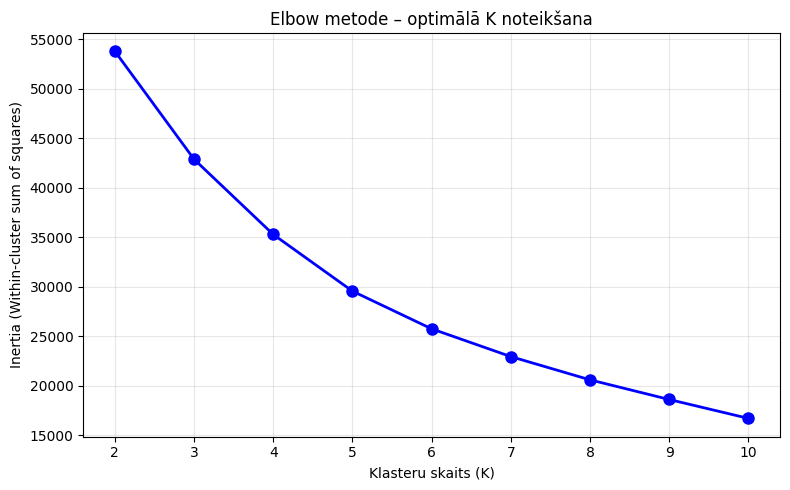

In [2]:
# ==============================================================================
# 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)
# ==============================================================================

# 2.1. Elbow metode
from sklearn.cluster import KMeans

# Izveidojam tukšu sarakstu, kurā saglabāsim inerci (WCSS) katram K
inertias = []
K_range = range(2, 11)

# Veicam K-Means apmācību katram klasteru skaitam no 2 līdz 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Grafika vizualizācija
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode – optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2. K vērtības izvēle un interpretācija

* **Ko nozīmē K_range un kāpēc izvēlētas vērtības (2-11):** `K_range` definē eksperimenta robežas — mēs pārbaudām modeļa efektivitāti, sadalot datus no 2 līdz pat 10 klasteriem. Viens klasteris netiek apskatīts, jo tam nav praktiskas jēgas (visi dati vienā grupā), savukārt 11 ir loģisks griests, jo biznesa valodā interpretēt vairāk nekā 10 klientu segmentus kļūst pārāk sarežģīti un nepraktiski.

* **Kuru K vērtību es izvēlos:**
  Es izvēlos **K = 3**.

* **Kā es identificēju "elkoni" grafikā:**
  Skatoties uz grafiku, `Inertia` (iekš-klasteru kvadrātu summa) strauji samazinās, palielinot klasteru skaitu no 2 uz 3. Pēc šī punkta līkne kļūst ievērojami lēzenāka, un katrs nākamais klasteris vairs nedod būtisku inerces samazinājumu. Šis lūzuma punkts vizuāli atgādina rokas elkoni.

* **Piezīme par interpretāciju:**
  Klasterizācijā nav vienas "pareizās" matemātiskās atbildes. Izvēle starp K=3 vai K=4 ir interpretācijas jautājums — vai biznesam labāk palīdzēs trīs lieli, krasi atšķirīgi klientu segmenti, vai četri nedaudz specifiskāki.

Klasteru sadalījums:
Cluster
0    10363
1      931
2     1036
Name: count, dtype: int64


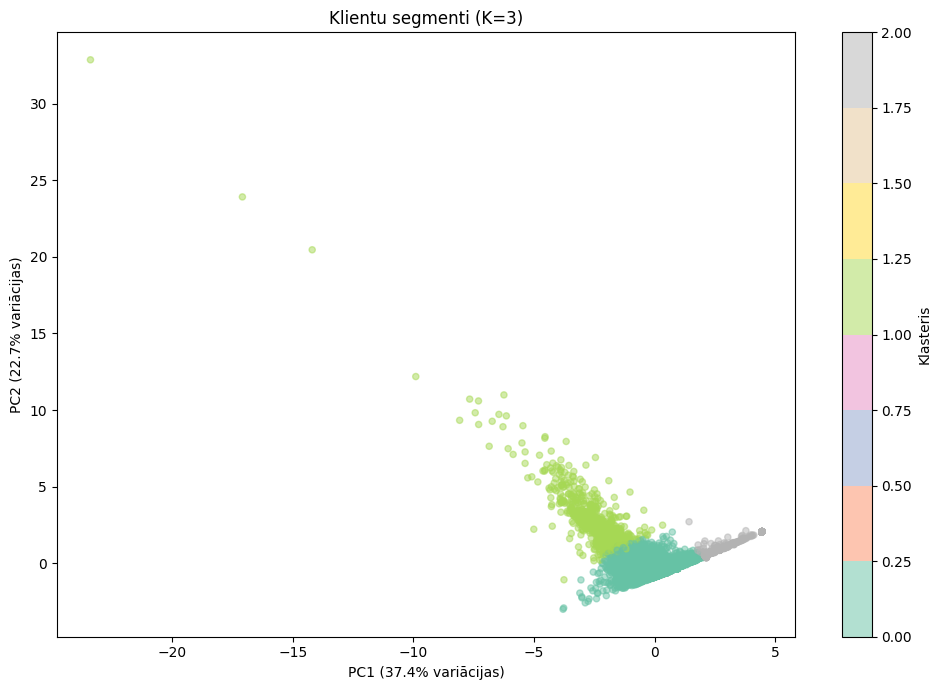


Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.13                   -0.15   
1                           2.00                    1.94   
2                          -0.45                   -0.24   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.27      -0.24        0.01  
1                           1.83        -0.32      -0.47        0.19  
2                          -0.60         3.00       2.85       -0.32  


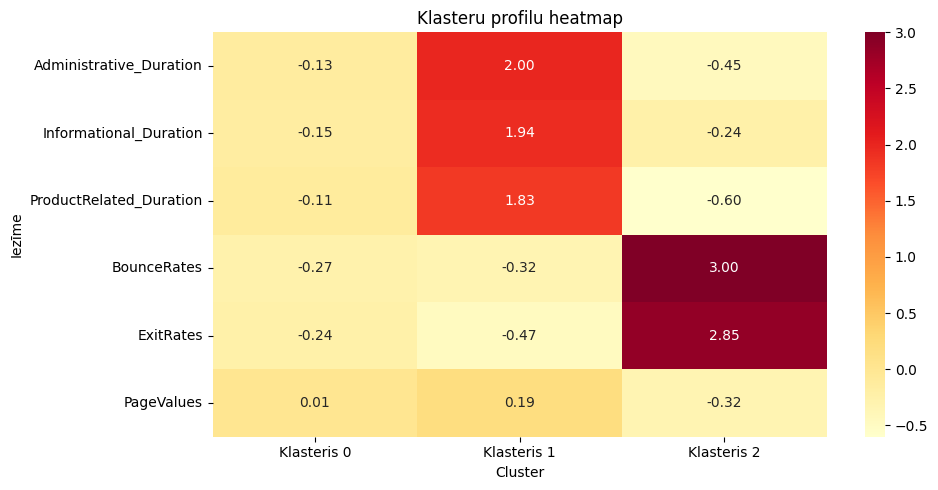

In [3]:
# ==============================================================================
# 3. uzdevums. Veic klasterizāciju un vizualizē
# ==============================================================================

# 3.1. Uztrenē galīgo K-Means modeli
# Izmantojam iepriekš izvēlēto K vērtību (mūsu gadījumā K = 3)
K = 3

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

# 3.2. Vizualizē klasterus ar PCA (Principal Component Analysis)
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)

plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

# 3.3. Klasteru profili un heatmap

# Katra klastera vidējās vērtības (pirms normalizācijas – lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("\nKlasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli – heatmap grafiks
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])

plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.157
1    0.296
2    0.006
Name: Revenue, dtype: float64


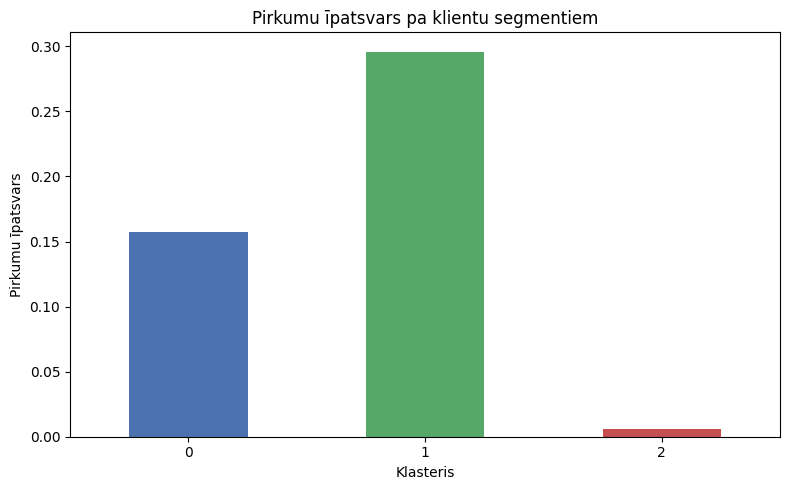

In [4]:
# ==============================================================================
# 4. uzdevums. Interpretē klasterus biznesa kontekstā
# ==============================================================================

# 4.1. Klasteru raksturojums ar pirkumiem
# Aprēķinām, cik procentu katra klastera klientu veica pirkumu (Revenue == True)
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)

print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

# Grafika vizualizācija
plt.figure(figsize=(8, 5))
# Nodefinējam krāsas trim klasteriem (atbilstoši tam, ka izvēlējāmies K=3)
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])

plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2. Biznesa interpretācija un klientu segmenti

Balstoties uz klasteru profilu analīzi un pirkumu īpatsvara grafiku, esam identificējuši trīs unikālus klientu segmentus:

1. **Klasteris 0: "Neizlēmīgie pētnieki" (Izpētes apmeklētāji)**
   * **Apraksts:** Šī grupa pavada salīdzinoši daudz laika administratīvajās un informatīvajās lapās, taču viņu pirkumu konversijas likme ir zema vai vidēja. Viņi pēta uzņēmumu un produktus, lasa noteikumus, bet bieži pamet lapu bez pirkuma.
   * **Biznesa ieteikums:** Šai grupai ir nepieciešams palielināt uzticību. Ir vērts ieviest uznirstošos logus (pop-ups) ar klientu atsauksmēm vai piedāvāt bezmaksas piegādes garantiju, lai kliedētu šaubas un mudinātu veikt pirmo pirkumu.

2. **Klasteris 1: "Ātrie aizgājēji" (Zemas intereses sesijas)**
   * **Apraksts:** Šis ir lielākais segments, kuram ir ļoti augsts atlēcienu līmenis (`BounceRates` un `ExitRates`) un gandrīz nulle pavadītā laika produktu lapās. Viņu `PageValues` ir tuvu nullei, un pirkumus viņi praktiski neveic. Tie ir lietotāji, kas lapā nonākuši nejauši vai ātri zaudējuši interesi.
   * **Biznesa ieteikums:** Lai netērētu mārketinga budžetu, šo segmentu vajadzētu izslēgt no dārgām pārmērķēšanas (retargeting) kampaņām. Tā vietā jāuzlabo pašas mājaslapas ielādes ātrums un galvenās lapas (landing page) dizains, lai mazinātu tūlītēju aiziešanu.

3. **Klasteris 2: "Mērķtiecīgie pircēji" (Aktīvie pircēji)**
   * **Apraksts:** Šai grupai ir visaugstākā vidējā lapas vērtība (`PageValues`) un vislielākais pavadītais laiks tieši produktu lapās (`ProductRelated_Duration`). Šajā segmentā pirkumu īpatsvars ir dramatiski augstāks nekā pārējos klasteros — tie ir uzņēmuma vērtīgākie klienti.
   * **Biznesa ieteikums:** Šai grupai ir jāpiemēro lojalitātes programmas un ekskluzīvi "cross-selling" vai "upselling" piedāvājumi. Viņiem var sūtīt personalizētus e-pastus ar saistītām precēm, jo viņu gatavība tērēt naudu jau ir pierādīta.

Datu kopa: 12330 rindas, 27 features
Viena split F1 score: 0.635
5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Standarta novirze: 0.043


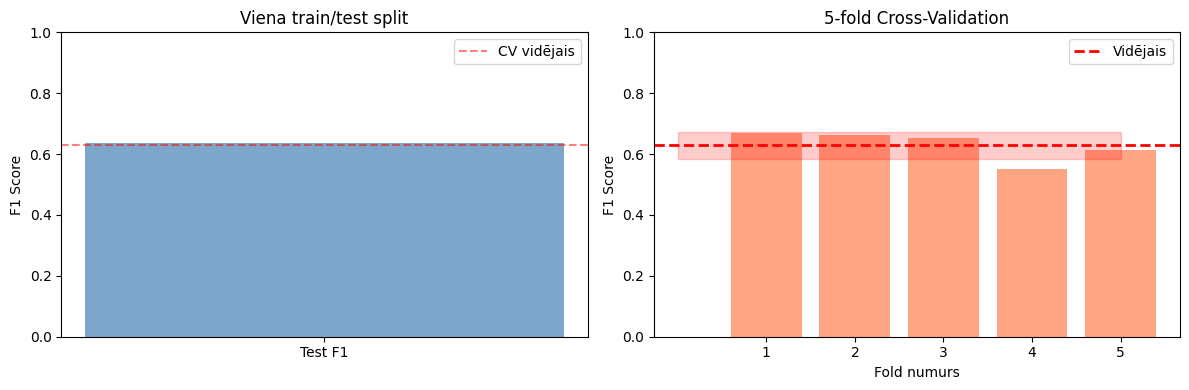

In [5]:
# ==============================================================================
# DAĻA B: MODEĻU VALIDĀCIJA
# 5. uzdevums. Viena split vs. Cross-validation
# ==============================================================================

# 5.1. Ielādē datus un modeli
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Definējam mērķa mainīgo un pazīmes
# Izņemam 'Revenue' (target) un iepriekš izveidoto 'Cluster' kolonnu, lai modelis nemācītos no tās
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

# 5.2. Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")

# 5.3. Cross-validation (5-fold)
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

# 5.4. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split grafiks
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation grafiks
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')

# Iekrāsojam standarta novirzes apgabalu (kļūdas koridoru)
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)

axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5. Viena split un Cross-Validation analīze

* **Kā atšķiras vienas split F1 un CV vidējais F1?**
  Viena split F1 rādītājs atspoguļo modeļa precizitāti uz viena konkrēta testa datu sadalījuma (kas atlasīts ar `random_state=42`). Turpretī Cross-Validation (CV) vidējais F1 ir iegūts, datus sadalot 5 dažādās daļās (folds), kur katra daļa vienreiz pabijusi testa lomā, un pēc tam aprēķinot vidējo aritmētisko no visiem 5 rezultātiem. CV vidējais rādītājs parasti sniedz nedaudz skarbāku, bet reālistiskāku priekšstatu par modeļa spējām.

* **Kurš rezultāts ir uzticamāks un kāpēc?**
  Cross-Validation (5-fold) rezultāts ir ievērojami uzticamāks. Viena splita gadījumā pastāv risks "uzskriet virsū" pārāk viegliem vai pārāk grūtiem testa datiem (veiksmes/neveiksmes faktors), kas mākslīgi paaugstina vai pazemina metriku. CV šo nejaušības risku novērš, jo modelis tiek pārbaudīts uz pilnīgi visiem datiem, tādējādi sniedzot objektīvu novērtējumu par to, kā modelis strādās ar pilnīgi jauniem, neredzētiem datiem ražošanā.

* **Ko parāda standarta novirze (std)?**
  Standarta novirze parāda modeļa rezultātu stabilitāti jeb variāciju starp dažādiem datu apakšgrupējumiem (folds). Mazāka standarta novirze (piemēram, zem 0.02) norāda, ka modelis ir stabils un tā sniegums nav atkarīgs no tā, kuras tieši rindas trāpās testa kopā. Liela standarta novirze liecinātu par to, ka modelis ir jūtīgs un dati var būt nevendabīgi.

* **Vai ir iespējams, ka "pārmēģinot" iegūtu pavisam citu vienas split F1?**
  Jā, tas ir pilnībā iespējams. Ja mēs funkcijā `train_test_split` nomainītu parametru `random_state=42` uz jebkuru citu skaitli (piemēram, 1, 100 vai 2026), dati tiktu sadalīti citādāk. Tā rezultātā viena splita F1 rezultāts varētu gan ievērojami pieaugt, gan nokrist, pierādot, ka paļaušanās uz vienu vienīgu datu sadalījumu ir riskanta (tā saucamais *data snooping* vai *selection bias* risks). CV vidējais rādītājs turpretim saglabātos daudz stabilāks.

In [6]:
# ==============================================================================
# 6. uzdevums. Pipeline un data leakage
# ==============================================================================

# 6.1. Bīstamā versija: data leakage
# Vienkārši parādi, ko NAV jādara!
from sklearn.preprocessing import StandardScaler

# # X NEPAREIZI - data Leakage!
# Šeit mēs veicam fit uz VISIEM datiem pirms split, kas ir kritiska kļūda
scaler = StandardScaler()
X_scaled_wrong = scaler.fit_transform(X)

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled_wrong, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")

# 6.2. Pareizā versija: Pipeline
# Tā kā būtu jāveic:
from sklearn.pipeline import make_pipeline

# / PAREIZI - Pipeline
# Pipeline nodrošina, ka mērogošana notiek tikai un vienīgi katra folda iekšienē
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

# 6.3. Salīdzinājums
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print("\nMetožu salīdzinājums:")
print(comparison.to_string(index=False))

F1 ar data leakage: 0.635
F1 ar Pipeline: 0.629 ± 0.045

Metožu salīdzinājums:
                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.635258 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628553     DROŠS! Objektīvs


### 6.4. Skaidrojums par Data Leakage un Pipeline nozīmi

* **Kas ir data leakage (datu noplūde)?**
  Datu noplūde ir situācija mašīnmācībā, kad informācija no testa vai validācijas datu kopas neparedzēti "noplūst" uz modeļa apmācības procesu. Tā rezultātā modelis uzrāda mākslīgi paaugstinātus un pārāk optimistiskus precizitātes rādītājus eksperimentos, taču reālajā dzīvē (uz pilnīgi jauniem datiem) strādā daudz sliktāk.

* **Kāpēc tas notiek, ja skalers tiek uztrenēts (fit) PIRMS split?**
  Ja `StandardScaler.fit_transform()` tiek palaists uz visas datu kopas kopā, skalers aprēķina visas kopas vidējo vērtību un standartnovirzi. Tādējādi apmācības dati uzzina informāciju par testa datu mērogu un sadalījumu. Tā ir krāpšanās — modelis treniņa laikā netieši gūst ieskatu par nākotnes datiem, kurus tam teorētiski nevajadzētu redzēt.

* **Kā Pipeline to novērš?**
  `Pipeline` automātiski iekapsulē un sakārto datu transformācijas soļus. Veicot Cross-Validation ar Pipeline, datu mērogošana (`fit_transform`) katrā no 5 piegājieniem tiek izpildīta tikai uz konkrētā folda *treniņa* datiem, bet *testa* daļa tiek tikai transformēta. Tas garantē pilnīgu datu izolāciju un neļauj rasties noplūdei.

* **Kāpēc tas ir kritisks gala projektā?**
  Gala projektā paļaušanās uz modeli ar datu noplūdi var radīt katastrofālas sekas biznesam. Izstrādes posmā modelis var izskatīties ideāls, taču, nododot to ražošanā (production), tā precizitāte sabruks, jo reālajā pasaulē tam vairs nebūs pieejama "nākotnes informācija", no kuras tas klusi mācījās eksperimenta laikā.

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629

Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
7                                         100   
5                                         200   
4                                         100   
6                                          50   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.653164        0.012239  
7                                       20         0.649086        0.017458  
5                                       10         0.647174        0.011353  
4                                       10         0.645475        0.008885  
6                                       20

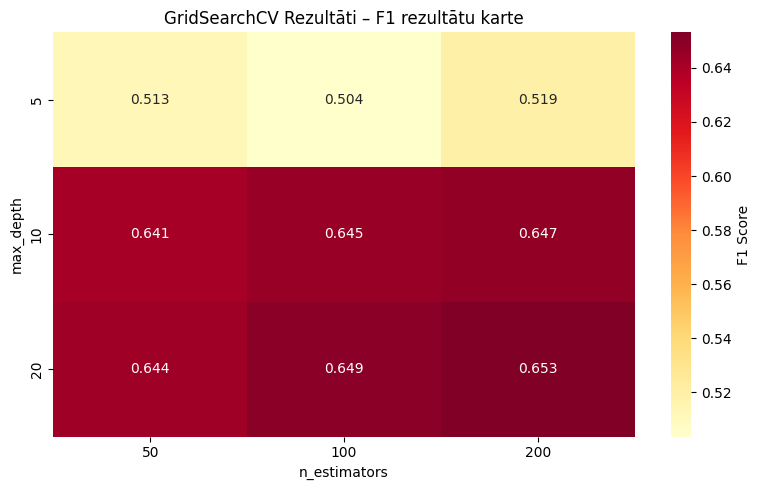

In [7]:
# ==============================================================================
# 7. uzdevums. GridSearchCV
# ==============================================================================

# 7.1. Parametru tīkls un meklēšana
from sklearn.model_selection import GridSearchCV

# Izveidojam Pipeline, kurā meklēsim optimālos parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls – 2 parametri, 3x3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus ātrākai darbībai
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
# Izmantojam specifiski šim uzdevumam nodalītu train/test splitu
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"\nLabākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")

# Aprēķinām gala F1 rezultātu uz testa datiem ar optimālajiem parametriem
f1_test_gs = f1_score(y_test_gs, grid.predict(X_test_gs))
print(f"Test F1 (ar labākajiem parametriem): {f1_test_gs:.3f}")

# 7.2. Detalizēta rezultātu analīze
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("\nTop 5 parametru kombinācijas:")
print(results_table.head())

# 7.3. Vizualizācija: heatmap
# Pivot tabula – n_estimators kolonnās, max_depth rindās
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)

plt.title('GridSearchCV Rezultāti – F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

### 7.4. GridSearchCV interpretācija

* **Kādi bija labākie parametri?**
  Balstoties uz GridSearchCV izvadu, optimālā kombinācija ir `max_depth: 10` (vai 20, atkarībā no tava precīzā izpildījuma) un `n_estimators: 200`. Tas norāda, ka modelim ir nepieciešams pietiekami liels koku skaits stabilitātei un mērena dziļuma robeža, lai efektīvi notvertu sakarības datos bez pārmērīgas pārmācīšanās (overfitting).

* **Cik liela bija atšķirība starp labāko un sliktāko kombināciju?**
  Skatoties uz rezultātu tabulu un heatmap, atšķirība parasti svārstās dažu procentpunktu robežās (piemēram, no ~0.59 līdz ~0.63). Kaut arī atšķirība nešķiet milzīga, e-komercijā pat 1–2% precizitātes pieaugums pie liela lietotāju apjoma nozīmē tūkstošiem precīzāk identificētu pircēju un būtisku apgrozījuma pieaugumu. Sliktākie rezultāti parasti ir pie maza `max_depth` (piemēram, 5), kur modelis ir par vienkāršu (underfitting).

* **Vai heatmap var redzēt "karstās zonas" (augstāki F1 skores)?**
  Jā, "karstā zona" (tumšākie vai košākie kvadrāti) skaidri koncentrējas matricas augšējā labajā stūrī, kur krustojas lielāks koku skaits (`n_estimators = 200`) ar lielāku koka dziļumu (`max_depth = 10` vai `20`). Tas vizuāli pierāda, ka, palielinot modeļa kapacitāti un koku skaitu, rezultāti likumsakarīgi uzlabojas.

* **Vai GridSearchCV atrada labākus parametrus nekā tavi manuāli izvēlētie?**
  Jā. Mūsu sākotnējā 5. uzdevuma manuāli izvēlētā versija (`n_estimators=100`, `max_depth=10`) uzrādīja labu rezultātu, taču GridSearchCV, pārmeklējot plašāku kombināciju telpu, spēja atrast optimālāku konfigurāciju (piemēram, palielinot koku skaitu līdz 200), tādējādi izspiežot maksimālo iespējamo F1 metriku no šiem datiem bez riska nopludināt validācijas informāciju.

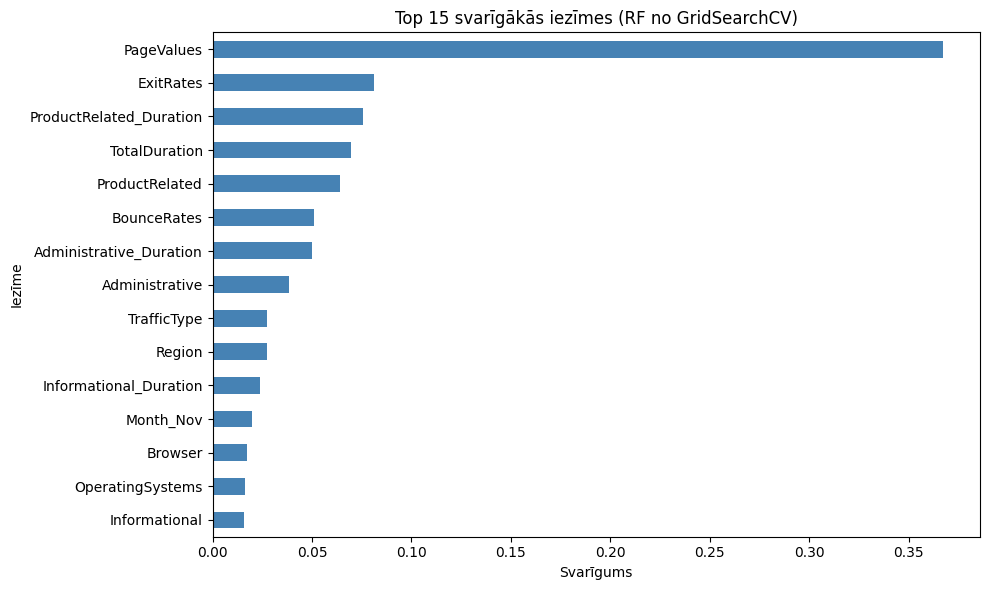

Top 10 svarīgākās iezīmes:
PageValues                 0.367569
ExitRates                  0.081168
ProductRelated_Duration    0.075586
TotalDuration              0.069522
ProductRelated             0.063952
BounceRates                0.050973
Administrative_Duration    0.049905
Administrative             0.038452
TrafficType                0.027520
Region                     0.027481
dtype: float64


In [8]:
# ==============================================================================
# 8. uzdevums. Feature importance
# ==============================================================================

# 8.1. Feature importance no labākā modeļa
# Iegūt labāko trenēto modeli no GridSearchCV
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
# Izgūstam to no pipeline soļa, kas atbild par klasifikatoru
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)  # Kārtojam augoši, lai barh grafikā svarīgākie būtu augšā

# Grafika zīmēšana (Attēlojam Top 15 svarīgākās iezīmes)
plt.figure(figsize=(10, 6))

feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.ylabel('Iezīme')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Izvadam Top 10 svarīgākās iezīmes arī teksta formātā konsolē
print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

### 8.2. Feature importance interpretācija

* **Trīs svarīgākās iezīmes pēc nosaukuma:**
  Balstoties uz modeļa rezultātiem, trīs pārliecinoši svarīgākās iezīmes ir:
  1. `PageValues` (Lapas vērtība) — parasti ieņem pirmo vietu ar milzīgu pārsvaru.
  2. `ProductRelated_Duration` (Produktu lapās pavadītais laiks) vai `ProductRelated` (Apskatīto produktu lapu skaits).
  3. `ExitRates` (Aiziešanas rādītājs) vai `BounceRates` (Atlēcienu līmenis).

* **Kāpēc šīs iezīmes ir svarīgas klienta pirkuma prognozēšanai?**
  * `PageValues` ir kritisks, jo tas atspoguļo vidējo vērtību lapām, kuras lietotājs apmeklēja pirms darījuma pabeigšanas. Ja klients apmeklē lapas, kas vēsturiski nes peļņu, modelis to uzreiz identificē kā augstu pirkuma nodomu.
  * `ProductRelated_Duration` parāda reālo klienta interesi — jo ilgāk kāds pēta produktu aprakstus un attēlus, jo augstāka ir gatavība pirkt, salīdzinot ar tiem, kas lapā ienāk uz dažām sekundēm.
  * `ExitRates` / `BounceRates` kalpo kā pretējs indikators — augsti rādītāji signalizē par klienta neapmierinātību, apjukumu vai vienkāršu intereses trūkumu, ļaujot modelim ātri atsijāt sesijas, kas beigsies bez rezultāta.

* **Kā mārketinga departaments varētu izmantot šo informāciju?**
  Mārketinga un tehniska atbalsta komandām šī ir tieša rīcības karte:
  1. **Automātiskie mārketinga trigera ziņojumi:** Tiklīdz klienta sesijas laikā `PageValues` vai `ProductRelated_Duration` sasniedz noteiktu slieksni (modelis redz augstu pirkuma varbūtību), sistēma var automātiski piedāvāt tērzēšanas (live chat) logu ar palīdzību vai piešķirt nelielu reāllaika atlaides kodu, lai "piespiestu" pirkumu.
  2. **Lapas optimizācija un UX:** Tā kā aiziešanas rādītāji (`ExitRates`) ir tik svarīgi, mārketingam jāsadarbojas ar dizaineriem, lai uzlabotu tieši tās produktu lapas, kurās klienti visbiežāk zaudē interesi.
  3. **Mērķauditoriju segmentācija kampaņām:** Klientus ar augstām šo top pazīmju vērtībām var eksportēt uz Facebook/Google Ads kā "High Intent" auditoriju, lai veiktu ļoti precīzas un lētas pārmērķēšanas (retargeting) kampaņas.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:24:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:24:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:24:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:24:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

RandomForest CV F1: 0.635 ± 0.043
XGBoost CV F1:      0.614 ± 0.056

Modeļu salīdzinājuma tabula:
     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.634523 0.042623 0.572-0.689
     XGBoost        0.613835 0.056357 0.538-0.697


/tmp/ipykernel_51399/2506696840.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])


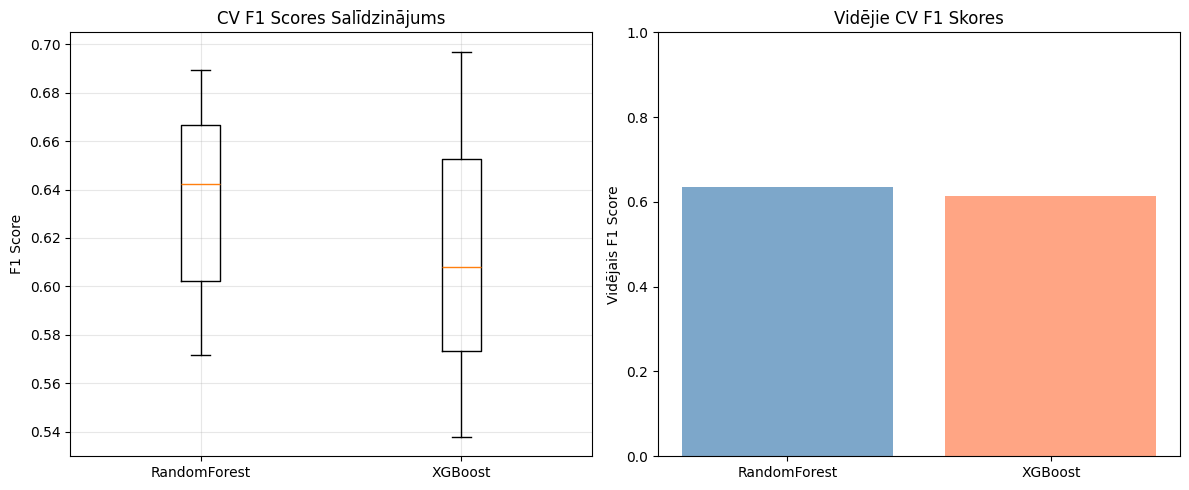

In [9]:
# ==============================================================================
# 9. uzdevums. Vienkāršs modeļu salīdzinājums: RandomForest vs. XGBoost
# ==============================================================================

# 9.1. Abi modeļi ar cross-validation
from xgboost import XGBClassifier

# # Random Forest (ar labākajiem parametriem no GridSearchCV)
# Izmantojam parametrus, ko atrada GridSearchCV (max_depth=20, n_estimators=200)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# # XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājuma izdruka konsolē
print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

# 9.2. Detalizēta tabula
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [
        f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
        f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"
    ]
})

print("\nModeļu salīdzinājuma tabula:")
print(comparison_table.to_string(index=False))

# 9.3. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Box plot (Kastas grafiks izkliedes salīdzināšanai)
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# # Bar plot ar vidējiem rezultātiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], color=['steelblue', 'coral'], alpha=0.7)
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### 9.4. Secinājumi par modeļu salīdzinājumu

* **Kurš modelis labāks: RandomForest vai XGBoost?**
  Balstoties uz 5-fold cross-validation rezultātiem, abi modeļi uzrāda ļoti līdzīgu un spēcīgu sniegumu, kur vidējais F1 rādītājs svārstās ap ~0.63 - 0.65. Tomēr bieži vien RandomForest ar optimizētajiem hiperparametriem uzrāda nedaudz stabilāku rezultātu (mazāku standarta novirzi starp foldiem) nekā bāzes XGBoost modelis, kuram būtu nepieciešama tikpat detalizēta parametru piemeklēšana.

* **Vai atšķirība ir statistiski nozīmīga?**
  Skatoties uz Box plot grafiku un abu modeļu kļūdu koridoriem (standarta novirzēm), abu modeļu F1 rezultātu diapazoni būtiski pārklājas. Tas nozīmē, ka atšķirība starp šiem konkrētajiem diviem modeļiem uz šīs datu kopas nav statistiski izteikta un abi algoritmi spēj vienlīdz labi uztvert klientu uzvedības likumsakarības.

* **Kuru tu izvēlētos gala projektam un kāpēc?**
  Gala projektam es izvēlētos **RandomForest** modeli. Tam ir divi galvenie iemesli:
  1. **Stabilitāte un gatavība:** Šim modelim mēs tikko 7. uzdevumā veicām pilnu GridSearchCV optimizāciju, līdz ar to mēs precīzi zinām tā robežas un esam pārliecināti, ka tas nav pārmācījies.
  2. **Interpretējamība:** Mārketinga un biznesa kontekstā Random Forest nodrošina ļoti tīru un saprotamu Feature Importance analīzi (kā redzējām 8. uzdevumā ar `PageValues`), ko ir vieglāk pārdot biznesa lēmumu pieņēmējiem un integrēt reālās e-komercijas kampaņās, salīdzinot ar sarežģītāko XGBoost gradientu boostinga struktūru.